In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/drom_archive_2007-2025.csv')

C:\Users\Sofia\AppData\Local\Temp\ipykernel_1992\222211504.py:1: DtypeWarning: Columns (0: Цвет, 1: VIN, 2: Проверено, 3: Номер кузова, 4: Владельцы) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/drom_archive_2007-2025.csv')


In [3]:
df.shape

(12147688, 58)

In [4]:
df.head()

,Название машины,Год,Ссылка,Дата размещения объявления,Цена,Кол-во просмотров,Скрыто,Объем двигателя,Тип двигателя,Мощность,...,Объем ковша,Длина стрелы,Грузоподъемность стрелы,Высота вышки,Состояние,Страна производства,Высота подъема,Ошибка_ст,Ошибка_знач,Пропуски в данных
0,Aston Martin DB9,2009.0,https://auto.drom.ru/vladivostok/aston_martin/...,2012-12-06,7876735.0,30.0,0.0,5.9,бензин,477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"7,","6.0,","9, 14, 15, 17, 20,"
1,Aston Martin DBS,2008.0,https://auto.drom.ru/moscow/aston_martin/dbs/9...,2013-01-29,9000000.0,763.0,0.0,5.9,бензин,517.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9, 14, 15, 17,"
2,Aston Martin DB9,2004.0,https://auto.drom.ru/krasnodar/aston_martin/db...,2015-11-29,1985000.0,363.0,0.0,5.9,бензин,456.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,","450.0,","14, 15, 17,"
3,Aston Martin DB9,2005.0,https://auto.drom.ru/moscow/aston_martin/db9/1...,2015-10-22,2586000.0,293.0,0.0,5.9,бензин,456.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,","450.0,","14, 15, 17,"
4,Aston Martin DB9,2005.0,https://auto.drom.ru/moscow/aston_martin/db9/1...,2015-10-26,2304000.0,464.0,0.0,5.9,бензин,456.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,","450.0,","14, 15, 17,"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12147688 entries, 0 to 12147687
Data columns (total 58 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Название машины             str    
 1   Год                         float64
 2   Ссылка                      str    
 3   Дата размещения объявления  str    
 4   Цена                        float64
 5   Кол-во просмотров           float64
 6   Скрыто                      float64
 7   Объем двигателя             float64
 8   Тип двигателя               str    
 9   Мощность                    float64
 10  Коробка передач             str    
 11  Привод                      str    
 12  Пробег                      float64
 13  Руль                        str    
 14  Поколение                   float64
 15  Рестайлинг                  float64
 16  Цвет                        str    
 17  Комплектация                str    
 18  Владелец                    str    
 19  Особые отметки              st

In [6]:
total_nan = df.isnull().sum().sum()
total_nan

np.int64(401548089)

In [7]:
# удалим ненужные столбцы
drp = [
    "Ссылка", "VIN", "Номер кузова",
    "Ошибка_ст", "Ошибка_знач", "Скрыто", "Проверено",
    "Кол-во просмотров", "Комплектация",
    "Особые отметки",
    "Рефрижератор", "Спальник", "Объем кузова",
    "Категория ТС", "Тип техники", "Колёсная формула",
    "Количество осей", "Масса", "Грузоподъемность",
    "Длина кузова", "Тип кабины", "Рабочая ширина",
    "Моточасы", "Оборудование", "Высота седла",
    "Бренд ХОУ", "Объем ковша", "Длина стрелы",
    "Грузоподъемность стрелы", "Высота вышки",
    "Высота подъема", "Ходовая часть",
    "Владелец","Топливо", "Регион", "Макро-регион", "Цвет", "Состояние", "Страна производства", "Количество мест", "Владельцы", "Пропуски в данных",
    "Рестайлинг", "Руль"
]

df = df.drop(columns=drp, errors="ignore")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12147688 entries, 0 to 12147687
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Название машины             str    
 1   Год                         float64
 2   Дата размещения объявления  str    
 3   Цена                        float64
 4   Объем двигателя             float64
 5   Тип двигателя               str    
 6   Мощность                    float64
 7   Коробка передач             str    
 8   Привод                      str    
 9   Пробег                      float64
 10  Поколение                   float64
 11  Тип кузова                  str    
 12  Метка                       str    
 13  Город                       str    
dtypes: float64(6), str(8)
memory usage: 1.3 GB


In [8]:
list(df['Тип кузова'].unique())

['купе//открытый кузов',
 'купе',
 'открытый',
 'лифтбек',
 nan,
 'открытый кузов',
 'джип/suv 5 дв.',
 'седан',
 'хэтчбек 3 дв.',
 'хэтчбек 5 дв.',
 'седан//универсал',
 'открытый кузов//седан//универсал',
 'универсал',
 'открытый кузов//хэтчбек 3 дв.',
 'купе//седан',
 'купе//лифтбек//открытый кузов',
 'хэтчбек 3 дв.//хэтчбек 5 дв.',
 'лифтбек//открытый кузов',
 'купе//лифтбек',
 'седан//хэтчбек 3 дв.',
 'открытый кузов//хэтчбек 3 дв.//хэтчбек 5 дв.',
 'открытый кузов//седан',
 'открытый кузов//седан//хэтчбек 3 дв.//хэтчбек 5 дв.',
 'седан//хэтчбек 5 дв.',
 'джип/suv 5 дв.//седан',
 'открытый кузов//седан//хэтчбек 5 дв.',
 'седан//хэтчбек 3 дв.//хэтчбек 5 дв.',
 'купе//лифтбек//седан',
 'купе//открытый кузов//седан',
 'купе//лифтбек//седан//универсал',
 'купе//открытый кузов//седан//универсал',
 'джип/suv 5 дв.//купе//открытый кузов//седан//универсал//хэтчбек 3 дв.//хэтчбек 5 дв.',
 'купе//седан//универсал',
 'купе//лифтбек//открытый кузов//седан//универсал',
 'лифтбек//седан//универ

In [9]:
# большое кол-во признаков через //, которые могут путать модель, а так же не легковые авто. удаляем
# список нужных типов кузова:
valid = [
    "купе", "лифтбек", "открытый", "открытый кузов",
    "седан", "хэтчбек 3 дв.", "хэтчбек 5 дв.",
    "универсал", "минивэн", "джип/suv 5 дв.", "джип/suv 3 дв."
]

# список для исключения (грузовые и спецтехника)
invalid = [
    "автобус", "грузовик", "бортовой", "шасси", "пикап", 
    "цельнометаллический", "фургон", "седельный тягач", "рефрижератор"
]

# удалим строки с //
df = df[~df["Тип кузова"].str.contains("//", na=False)]

# удалим строки с грузовым авто
mask_invalid = df["Тип кузова"].str.contains("|".join(invalid), case=False, na=False)
df = df[~mask_invalid]

# оставляем только нужные легковые кузовы
df = df[df["Тип кузова"].isin(valid)]

df["Тип кузова"].value_counts()

Тип кузова
седан             4896968
джип/suv 5 дв.    2496446
хэтчбек 5 дв.     2057755
универсал          948642
минивэн            760675
джип/suv 3 дв.     233784
лифтбек            230988
хэтчбек 3 дв.      160312
купе                72735
открытый             4233
открытый кузов       3922
Name: count, dtype: int64

In [10]:
# поскольку у нас огромное кол-во данных (12_147_688), можем просто удалить строки с пропущенными данными хотя бы в одной колонке
req_col = list(df.columns)
df = df.dropna(subset=req_col)
df.shape

(11189638, 14)

In [11]:
total_nan = df.isnull().sum().sum()
total_nan # в датасете теперь отсутсвуют пропуски 

np.int64(0)

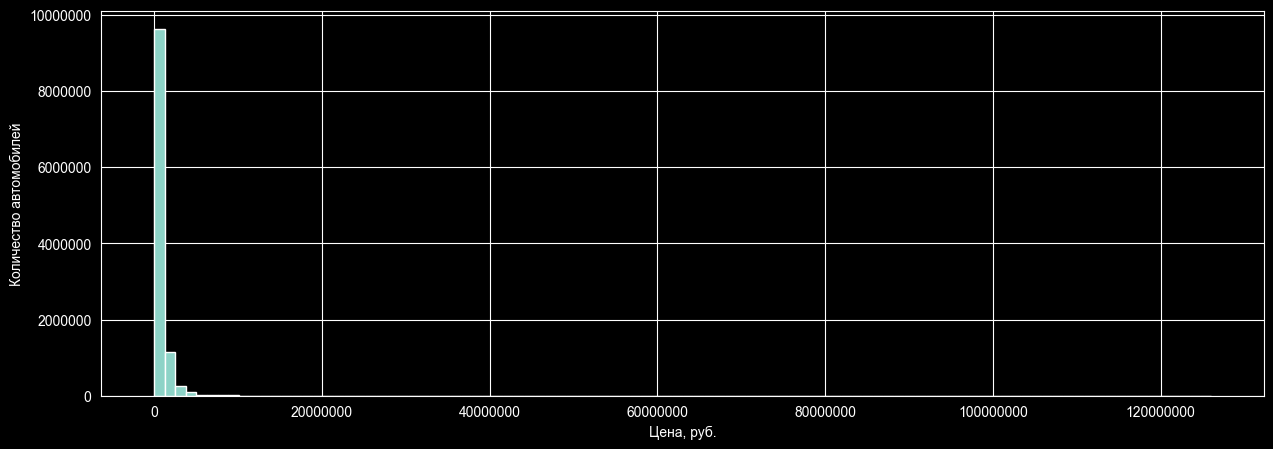

In [12]:
plt.figure(figsize=(15,5))
plt.hist(df["Цена"], bins=100)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')# показывает обычные числа на оси Y
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")
plt.show()
# по гистограмме можно заметить, что есть очень малое кол-во аномально дорогих авто. это может существенно понизить точность предсказаний

In [13]:
# обрежем цену с 500_000 до 3_000_000
df = df[(df["Цена"] >= 500_000) & (df["Цена"] <= 3_000_000)]

# уберем новые авто с низким пробегом
df = df[df["Пробег"] > 2_000]

# удалим аномалии с объёмом двигателя меньше 0,6 л
df = df[(df['Объем двигателя'] >= 0.6) & (df['Объем двигателя'] < 8)]

df = df[(df['Тип двигателя'] != 'электро') & 
    (df['Тип двигателя'] != 'газ/бензин') & 
    (df['Тип двигателя'] != 'ГБО') & 
    (df['Тип двигателя'] != 'газ')]
print(df['Тип двигателя'].unique())

df = df[(df['Название машины'] != 'Ford Focus') 
    & (df['Дата размещения объявления'] != '2023-05-21')]

<StringArray>
['бензин', 'дизель']
Length: 2, dtype: str


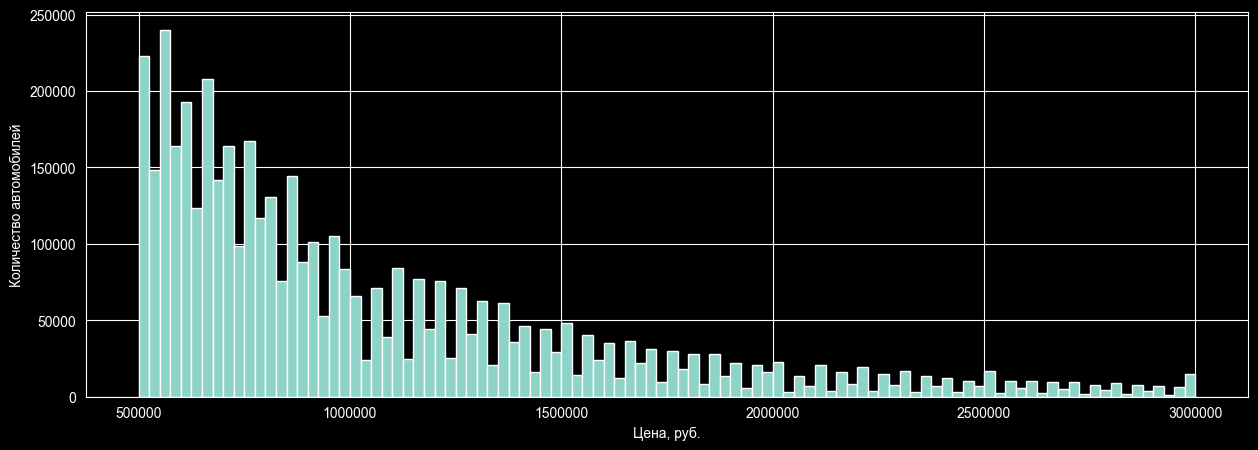

In [14]:
plt.figure(figsize=(15,5))
plt.hist(df["Цена"], bins=100)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')# показывает обычные числа на оси Y
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")
plt.show()

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 4540780 entries, 2 to 12147686
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Название машины             str    
 1   Год                         float64
 2   Дата размещения объявления  str    
 3   Цена                        float64
 4   Объем двигателя             float64
 5   Тип двигателя               str    
 6   Мощность                    float64
 7   Коробка передач             str    
 8   Привод                      str    
 9   Пробег                      float64
 10  Поколение                   float64
 11  Тип кузова                  str    
 12  Метка                       str    
 13  Город                       str    
dtypes: float64(6), str(8)
memory usage: 519.7 MB


In [16]:
# преобразуем колонку с датой в соответствующий тип и уберем данные до 18го года
df["Дата размещения объявления"] = pd.to_datetime(df["Дата размещения объявления"], format='%Y-%m-%d')
df = df[df["Дата размещения объявления"].dt.year >= 2018]

In [17]:
df["Дата размещения объявления"] = pd.to_datetime(df["Дата размещения объявления"])
df["Год объявления"] = df["Дата размещения объявления"].dt.year
df["Возраст авто"] = df["Год объявления"] - df["Год"]

In [18]:
df['Метка'].unique()

<StringArray>
[ 'aston_martin',          'audi',       'bentley',           'bmw',
           'byd',      'cadillac',         'chery',     'chevrolet',
       'citroen',       'ferrari',          'ford',         'geely',
       'genesis',         'haval',         'honda',        'hongqi',
       'hyundai',      'infiniti',        'jaguar',          'jeep',
           'kia',          'lada',   'lamborghini',    'land_rover',
         'lexus',            'li',         'lotus',      'maserati',
         'mazda', 'mercedes-benz',    'mitsubishi',        'nissan',
       'peugeot',       'porsche',       'renault',   'rolls-royce',
         'skoda',        'subaru',        'suzuki',        'toyota',
    'volkswagen',         'volvo']
Length: 42, dtype: str

In [19]:
df['Модель'] = df['Название машины'].map(lambda x: " ".join(x.split()[1:]) if x.split()[0] not in ('Aston', 'Land') else " ".join(x.split()[2:]))
df

,Название машины,Год,Дата размещения объявления,Цена,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Поколение,Тип кузова,Метка,Город,Год объявления,Возраст авто,Модель
40,Aston Martin DB9,2005.0,2019-10-17,1900000.0,5.9,бензин,456.0,АКПП,задний,48000.0,1.0,купе,aston_martin,Москва,2019,14.0,DB9
41,Aston Martin DB9,2007.0,2019-10-17,1971000.0,5.9,бензин,456.0,АКПП,задний,30000.0,1.0,купе,aston_martin,Ставрополь,2019,12.0,DB9
42,Aston Martin DB9,2005.0,2020-04-13,2900000.0,5.9,бензин,456.0,АКПП,задний,60000.0,1.0,купе,aston_martin,Краснодар,2020,15.0,DB9
48,Aston Martin DB9,2006.0,2021-08-15,1650000.0,5.9,бензин,456.0,АКПП,задний,38000.0,1.0,открытый,aston_martin,Москва,2021,15.0,DB9
54,Aston Martin DB9,2005.0,2021-01-15,2950000.0,5.9,бензин,456.0,АКПП,задний,30000.0,1.0,открытый,aston_martin,Сочи,2021,16.0,DB9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12147680,Volvo V70,2012.0,2025-05-31,950000.0,1.6,бензин,180.0,МКПП,передний,78000.0,3.0,универсал,volvo,Владивосток,2025,13.0,V70
12147682,Volvo XC70,2013.0,2025-06-24,1500000.0,2.4,дизель,163.0,АКПП,4WD,263500.0,3.0,универсал,volvo,Красноярск,2025,12.0,XC70
12147683,Volvo XC90,2006.0,2025-07-03,950000.0,2.5,бензин,210.0,АКПП,4WD,210000.0,1.0,джип/suv 5 дв.,volvo,Москва,2025,19.0,XC90
12147684,Volvo C30,2008.0,2025-07-02,700000.0,1.6,бензин,100.0,МКПП,передний,257500.0,1.0,хэтчбек 3 дв.,volvo,Сочи,2025,17.0,C30


In [20]:
df = df.drop(columns=["Название машины", "Дата размещения объявления"])
df_main = df.reset_index(drop=True)
df_main.info()
df_main.to_csv("data/drom_archive_cleaned_2018-2025full.csv", index=False)
df_slice = df_main.sample(n=1_000_000, random_state=42)
df_slice.to_csv("data/drom_archive_cleaned_2018-2025.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 4395695 entries, 0 to 4395694
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Год              float64
 1   Цена             float64
 2   Объем двигателя  float64
 3   Тип двигателя    str    
 4   Мощность         float64
 5   Коробка передач  str    
 6   Привод           str    
 7   Пробег           float64
 8   Поколение        float64
 9   Тип кузова       str    
 10  Метка            str    
 11  Город            str    
 12  Год объявления   int32  
 13  Возраст авто     float64
 14  Модель           str    
dtypes: float64(7), int32(1), str(7)
memory usage: 486.3 MB
